In [46]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure, figaspect
from scipy import signal
import librosa
import librosa.display
import IPython.display as ipd

from IPython.display import Audio, display

%matplotlib inline

In [73]:
def plot_mag_spectrum(x, fs, n_fft=None, title=None, xlim=None):
    """Plot a one-sided magnitude spectrum in dB."""
    if n_fft is None:
        n_fft = int(2**np.ceil(np.log2(len(x))))
    X = np.fft.fft(x, n=n_fft)
    f = np.fft.fftfreq(n_fft, d=1/fs)
    plt.figure(figsize=(10,3))
    plt.plot(f, np.abs(X))
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude (dB)")
    if title: plt.title(title)
    if xlim: plt.xlim(xlim)
    plt.grid(True, alpha=0.3)
    plt.show()
    return f, X

def show_fft2_logmag(img, title=None):
    """Show log-magnitude of 2D FFT (centered)."""
    F = np.fft.fftshift(np.fft.fft2(img))
    mag = np.log1p(np.abs(F))
    plt.figure(figsize=(4,4))
    plt.imshow(mag, cmap='gray')
    plt.axis('off')
    if title: plt.title(title)
    plt.show()

def psnr(x, y, data_range=1.0):
    mse = np.mean((x - y)**2)
    if mse == 0:
        return np.inf
    return 10*np.log10((data_range**2) / mse)

In [74]:
def encode_symbol(bits, bits_per_symbol):
    assert (len(bits) == bits_per_symbol), "Length of bit array must match bits per symbol."
    assert (bits_per_symbol % 2 == 0), "Bits per symbol must be even."
    
    def inverse_gray(n):
        """
        Converts a Gray coded integer to its binary equivalent.
        """
        mask = n
        while mask > 0:
            mask >>= 1
            n ^= mask
        return n
    
    # Upper bits represent in-phase amplitude
    # Lower bits represent quadrature amplitude
    I_bits = bits[: bits_per_symbol//2]
    Q_bits = bits[bits_per_symbol//2 : ]
    
    # Convert bit array to integer
    I_gray, Q_gray = 0, 0
    for i in range(bits_per_symbol // 2):
        I_gray = I_gray << 1 | I_bits[i]
        Q_gray = Q_gray << 1 | Q_bits[i]
    
    # If you look at a constellation diagram for QAM, you can think of the
    # symbols as a grid we can index into. The value represented by the
    # symbol is its index gray-coded. So if we want to represent a value,
    # we take its inverse gray code to figure out which symbol it should map to
    I_idx = inverse_gray(I_gray)
    Q_idx = inverse_gray(Q_gray)
    
    # Map indices to amplitudes
    L = 2 ** (bits_per_symbol//2)
    I = I_idx * 2 - (L - 1)
    Q = Q_idx * 2 - (L - 1)
    
    # TODO: Scaling / Normalize
    
    return I + 1j * Q

assert encode_symbol([0] * 6, 6) == (-7 - 7j)
assert encode_symbol([1,0,0] * 2, 6) == (7 + 7j)
assert encode_symbol([0,0,1,1,0,1], 6) == (-5 + 5j)
assert encode_symbol([0,1,1,1], 4) == (-1 + 1j)

In [75]:
def decode_symbol(symbol, bits_per_symbol):
    assert (bits_per_symbol % 2 == 0), "Bits per symbol must be even."
    def to_gray(n):
        return n ^ (n >> 1)
    
    # Get in-phase and quadrature component from complex symbol
    # TODO: If we normalized symbols, this logic breaks because IQ samples won't be integers
    I = int(np.round(np.real(symbol)))
    Q = int(np.round(np.imag(symbol)))
    
    # Convert I,Q samples to indices in constellation grid (symbol)
    L = 2 ** (bits_per_symbol//2)
    I_idx = (I + (L - 1)) // 2
    Q_idx = (Q + (L - 1)) // 2
    
    # Gray code of the indicies is the value encoded in the symbol
    I_val = to_gray(I_idx)
    Q_val = to_gray(Q_idx)
    
    # Combine upper and lower half into single integer
    k = (bits_per_symbol // 2)
    value = (I_val << k) + Q_val
    
    # Convert int to zero padded bit array
    bitarray = [int(bit) for bit in bin(value)[2:].zfill(bits_per_symbol)]
    
    return bitarray

print(decode_symbol(-5 + 5j, 6))
print(encode_symbol([0,0,1,1,0,1], 6))

[0, 0, 1, 1, 0, 1]
(-5+5j)


In [ ]:
def encode_bytestring(bytestring, bits_per_symbol):
    """
    Converts a sequence of bytes into a sequence of symbols of a specified bit length.
    
    Args:
        bytestring (bytes or bytearray): The raw input data to be encoded.
        bits_per_symbol (int): The number of bits each output symbol should contain.
            
    Returns:
        list of symbols: An array of complex symbols
    """
    # TODO: convert bytes string to bit array
    
    # TODO: Split bit array into N 'bits_per_symbol' length bit arrays
    
    # TODO: use encode_symbol() to encode each bit array
    
    
    return ... # Array of symbols created above

In [82]:
def decode_symbol_array(symbols, bits_per_symbol):
    
    return ...

In [83]:
def modulate_symbol(duration, carrier_freq, symbol, sample_rate=44100):
    
    return ...

In [84]:
def demodulate_symbol(carrier_freq, bits_per_symbol, sample_rate=44100):
    
    return ...

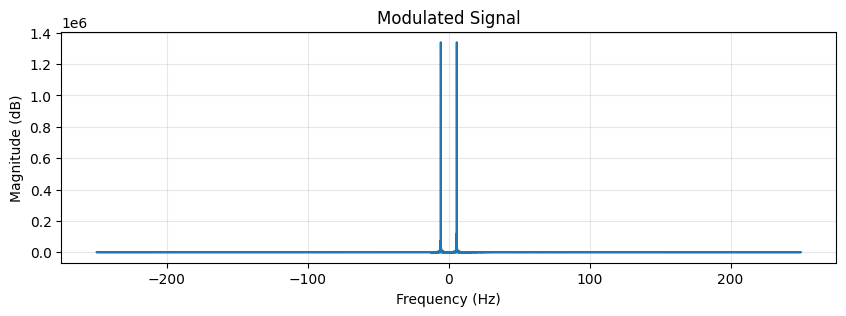

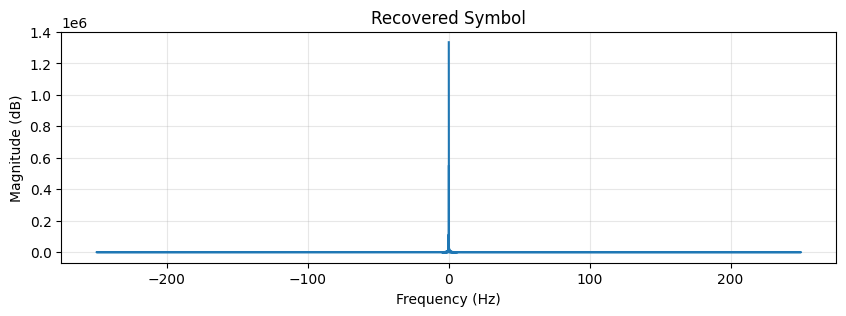

(42.798646038322424+42.79767264093148j)
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [81]:
# Carrier signal parameters
duration = 1.0
carrier_freq = 500.0
sample_rate = 44100
num_samples = int(duration * sample_rate)
t = np.linspace(0, duration, num_samples, endpoint=False)

# Modulation parameters
bits_per_symbol = 14
symbol = encode_symbol([1] * 14, bits_per_symbol)

# Modulate symbol onto carrier
carrier = np.exp(2j * np.pi * carrier_freq * t)
modulated = np.real(carrier * symbol) # Can only play real audio values

# Demodulate
demodulated = modulated * np.exp(-2j * np.pi * carrier_freq * t)

# Filter copies created by taking the real part of the complex symbol
numtaps = 401
cutoff_hz = 500 # TODO: find better value
h = signal.firwin(numtaps, cutoff_hz, fs=sample_rate)
filtered = signal.lfilter(h, [1.0], demodulated)

# Plot
plot_mag_spectrum(modulated, carrier_freq, title="Modulated Signal")
plot_mag_spectrum(filtered, carrier_freq, title="Recovered Symbol")

# Recover symbol, accounting for magnitude
recovered_symbol = np.mean(filtered) * 2 # TODO: why 2x factor?
print(recovered_symbol)
print(decode_symbol(recovered_symbol, bits_per_symbol))

display(Audio(modulated, rate=sample_rate))

In [ ]:
def extract_payload():
    # Autocorrelate to find preamble, return aligned signal
    
    # Should probably also return the amplitude of chirp/preamble, as
    # well as magnitude response for channel correction
    
    return ...